# Análise de Seleção de Fornecedor — Previsão de Demanda

**Objetivo:** Avaliar a qualidade de previsão de 3 fornecedores candidatos a sistema de previsão de demanda, utilizando 17 semanas de dados reais (ground truth) para calcular métricas de acurácia e recomendar o melhor fornecedor.

---

## 1. Carga e Limpeza dos Dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

FORNECEDORES = ['FORNECEDOR_01', 'FORNECEDOR_02', 'FORNECEDOR_03']
CORES = {'FORNECEDOR_01': '#2196F3', 'FORNECEDOR_02': '#FF9800', 'FORNECEDOR_03': '#4CAF50'}
LABELS = {'FORNECEDOR_01': 'Forn. 01', 'FORNECEDOR_02': 'Forn. 02', 'FORNECEDOR_03': 'Forn. 03'}

In [2]:
sku = pd.read_csv('CASE_01.csv')
sku.columns = sku.columns.str.strip()
print(f'Cadastro SKUs: {sku.shape[0]} materiais')
display(sku.head(3))
print('\nDistribuição Classe ABC:')
display(sku['CLASS_ABC'].value_counts())

Cadastro SKUs: 196 materiais


,MATERIAL,CATEGORIA,SUBCATEG,MARCA,CLASS_ABC
0,166,anon_S0,anon_S1313,anon_S6232,C
1,25,anon_S0,anon_S1313,anon_S2014,C
2,80,anon_S0,anon_S1313,anon_S7038,C



Distribuição Classe ABC:


CLASS_ABC
C    93
A    72
B    29
D     2
Name: count, dtype: int64

In [3]:
df_raw = pd.read_csv(
    'CASE_01_DATA.csv',
    decimal=',',
    thousands=None
)
df_raw.columns = df_raw.columns.str.strip()
print(f'Dados brutos: {df_raw.shape[0]:,} linhas x {df_raw.shape[1]} colunas')
display(df_raw.head(3))
print('\nTipos:')
display(df_raw.dtypes)

Dados brutos: 147,713 linhas x 10 colunas


,LOJA,ESTADO,MATERIAL,TEMPO,CAMPANHA_FLAG,CAMPANHA_DESCONTO,VOLUME_REAL,VOLUME_FORNECEDOR_01,VOLUME_FORNECEDOR_02,VOLUME_FORNECEDOR_03
0,1,SP,1,201702,1,29.2,374,436.8,200,431.656
1,1,SP,1,201703,0,0.0,130,78.0,2,72.316
2,1,SP,1,201704,0,0.0,64,64.0,0,92.502



Tipos:


LOJA                      int64
ESTADO                   object
MATERIAL                  int64
TEMPO                     int64
CAMPANHA_FLAG             int64
CAMPANHA_DESCONTO       float64
VOLUME_REAL               int64
VOLUME_FORNECEDOR_01    float64
VOLUME_FORNECEDOR_02      int64
VOLUME_FORNECEDOR_03    float64
dtype: object

In [4]:
vol_cols = ['VOLUME_REAL', 'VOLUME_FORNECEDOR_01', 'VOLUME_FORNECEDOR_02', 'VOLUME_FORNECEDOR_03']
for col in vol_cols:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

df = df_raw.merge(sku[['MATERIAL', 'CATEGORIA', 'SUBCATEG', 'MARCA', 'CLASS_ABC']], on='MATERIAL', how='left')

print(f'Após merge: {df.shape[0]:,} linhas')
print(f'Nulos por coluna:')
display(df[vol_cols].isnull().sum())

df = df.dropna(subset=['VOLUME_REAL'])
df = df[df['VOLUME_REAL'] >= 0].copy()

for col in ['VOLUME_FORNECEDOR_01', 'VOLUME_FORNECEDOR_02', 'VOLUME_FORNECEDOR_03']:
    df[col] = df[col].clip(lower=0)

df['TEMPO'] = df['TEMPO'].astype(str)
df['CAMPANHA_FLAG'] = df['CAMPANHA_FLAG'].astype(int)

df_antes_outliers = df.copy()

def calcular_limites_iqr(group):
    Q1 = group['VOLUME_REAL'].quantile(0.25)
    Q3 = group['VOLUME_REAL'].quantile(0.75)
    IQR = Q3 - Q1
    fator = np.where(group['CAMPANHA_FLAG'] == 1, 2.5, 1.5)
    group = group.copy()
    group['_lower'] = Q1 - fator * IQR
    group['_upper'] = Q3 + fator * IQR
    return group

df = df.groupby('MATERIAL', group_keys=False).apply(calcular_limites_iqr)

outlier_mask = (df['VOLUME_REAL'] < df['_lower']) | (df['VOLUME_REAL'] > df['_upper'])
n_outliers = outlier_mask.sum()

for col in ['VOLUME_FORNECEDOR_01', 'VOLUME_FORNECEDOR_02', 'VOLUME_FORNECEDOR_03']:
    df[col] = df[col].clip(upper=df['_upper'])

df = df[~outlier_mask].drop(columns=['_lower', '_upper']).copy()

print(f'\nRegistros válidos (antes de outliers): {len(df_antes_outliers):,}')
print(f'Outliers removidos (VOLUME_REAL): {n_outliers:,} ({n_outliers/len(df_antes_outliers):.1%})')
print(f'Registros após remoção: {df.shape[0]:,}')
print(f'Semanas: {sorted(df["TEMPO"].unique())}')
print(f'Lojas: {df["LOJA"].nunique()} | Materiais: {df["MATERIAL"].nunique()} | Estados: {df["ESTADO"].nunique()}')


Após merge: 147,713 linhas
Nulos por coluna:


VOLUME_REAL             0
VOLUME_FORNECEDOR_01    0
VOLUME_FORNECEDOR_02    0
VOLUME_FORNECEDOR_03    0
dtype: int64


Registros válidos (antes de outliers): 147,713
Outliers removidos (VOLUME_REAL): 7,983 (5.4%)
Registros após remoção: 139,730
Semanas: ['201702', '201703', '201704', '201705', '201706', '201707', '201708', '201709', '201710', '201711', '201712', '201713', '201714', '201715', '201716', '201717', '201718']
Lojas: 94 | Materiais: 196 | Estados: 16


### Diagnóstico de Outliers

=== DIAGNÓSTICO DE OUTLIERS (IQR por Material) ===
Método: IQR por SKU — fator 1.5x (normal) / 2.5x (campanha)

Total antes :    147,713 registros
Total depois:    139,730 registros
Removidos   :      7,983 (5.4%)

Outliers removidos por Classe ABC:
  Classe A: 3,557 removidos (44.6% dos outliers)
  Classe B: 1,509 removidos (18.9% dos outliers)
  Classe C: 2,876 removidos (36.0% dos outliers)
  Classe D: 41 removidos (0.5% dos outliers)

Estatísticas VOLUME_REAL — Antes vs Depois:


,Antes,Depois
count,147713.0,139730.0
mean,88.6,62.0
std,316.6,110.6
min,0.0,0.0
25%,14.0,12.0
50%,32.0,30.0
75%,78.0,66.0
max,27912.0,2200.0


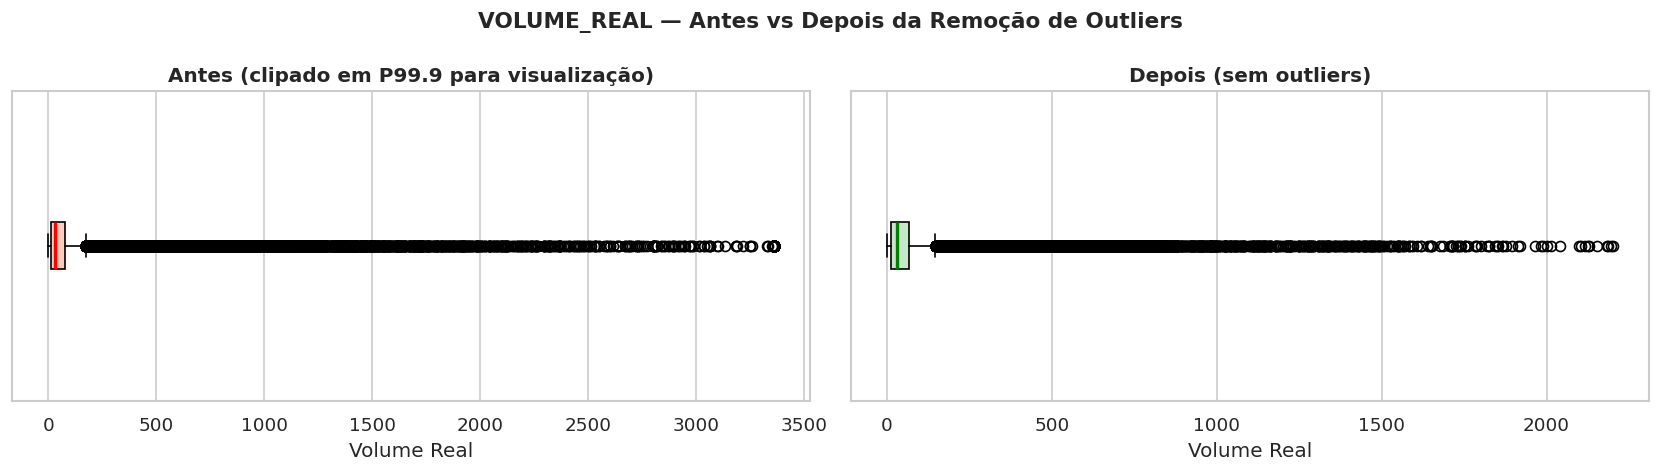

In [5]:
print('=== DIAGNÓSTICO DE OUTLIERS (IQR por Material) ===')
print(f'Método: IQR por SKU — fator 1.5x (normal) / 2.5x (campanha)')
print()

antes = df_antes_outliers
depois = df

print(f'Total antes : {len(antes):>10,} registros')
print(f'Total depois: {len(depois):>10,} registros')
print(f'Removidos   : {len(antes)-len(depois):>10,} ({(len(antes)-len(depois))/len(antes):.1%})')
print()

print('Outliers removidos por Classe ABC:')
ids_depois = set(depois.index)
outliers_df = antes[~antes.index.isin(ids_depois)]
if 'CLASS_ABC' in outliers_df.columns:
    abc_cnt = outliers_df['CLASS_ABC'].value_counts()
    abc_pct = outliers_df['CLASS_ABC'].value_counts(normalize=True)
    for cls in sorted(abc_cnt.index):
        print(f'  Classe {cls}: {abc_cnt[cls]:,} removidos ({abc_pct[cls]:.1%} dos outliers)')
print()

print('Estatísticas VOLUME_REAL — Antes vs Depois:')
stats = pd.DataFrame({
    'Antes': antes['VOLUME_REAL'].describe(),
    'Depois': depois['VOLUME_REAL'].describe(),
}).round(1)
display(stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('VOLUME_REAL — Antes vs Depois da Remoção de Outliers', fontsize=13, fontweight='bold')

axes[0].boxplot(antes['VOLUME_REAL'].clip(upper=antes['VOLUME_REAL'].quantile(0.999)),
                vert=False, patch_artist=True,
                boxprops=dict(facecolor='#FFCCBC'), medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Antes (clipado em P99.9 para visualização)', fontweight='bold')
axes[0].set_xlabel('Volume Real')
axes[0].set_yticks([])

axes[1].boxplot(depois['VOLUME_REAL'],
                vert=False, patch_artist=True,
                boxprops=dict(facecolor='#C8E6C9'), medianprops=dict(color='green', linewidth=2))
axes[1].set_title('Depois (sem outliers)', fontweight='bold')
axes[1].set_xlabel('Volume Real')
axes[1].set_yticks([])

plt.tight_layout()
plt.savefig('fig_00_outliers_diagnostico.png', bbox_inches='tight')
plt.show()


In [6]:
print('Estatísticas descritivas dos volumes:')
display(df[vol_cols].describe().round(2))

Estatísticas descritivas dos volumes:


,VOLUME_REAL,VOLUME_FORNECEDOR_01,VOLUME_FORNECEDOR_02,VOLUME_FORNECEDOR_03
count,139730.00,139730.00,139730.00,139730.00
mean,61.99,68.25,66.72,91.54
std,110.60,112.47,126.55,164.36
min,0.00,0.00,0.00,0.00
25%,12.00,15.60,8.00,18.48
50%,30.00,34.00,26.00,42.28
75%,66.00,74.00,74.00,98.71
max,2200.00,2224.00,2224.00,2224.00


## 2. Métricas de Acurácia Global

In [7]:
def wape(real, prev):
    total_real = real.sum()
    if total_real == 0:
        return np.nan
    return np.abs(real - prev).sum() / total_real

def forecast_accuracy(real, prev):
    return max(0, 1 - wape(real, prev))

def bias(real, prev):
    total_real = real.sum()
    if total_real == 0:
        return np.nan
    return (prev - real).sum() / total_real

def mae(real, prev):
    return np.abs(real - prev).mean()

def rmse(real, prev):
    return np.sqrt(((real - prev) ** 2).mean())

def mape_safe(real, prev):
    mask = real > 0
    if mask.sum() == 0:
        return np.nan
    return (np.abs((real[mask] - prev[mask]) / real[mask])).mean()

metricas_globais = []
for forn in FORNECEDORES:
    col = f'VOLUME_{forn}'
    real = df['VOLUME_REAL']
    prev = df[col]
    metricas_globais.append({
        'Fornecedor': LABELS[forn],
        'WAPE': wape(real, prev),
        'FA (Forecast Accuracy)': forecast_accuracy(real, prev),
        'Bias': bias(real, prev),
        'MAE': mae(real, prev),
        'RMSE': rmse(real, prev),
        'MAPE': mape_safe(real, prev),
    })

met_df = pd.DataFrame(metricas_globais).set_index('Fornecedor')
print('=== MÉTRICAS GLOBAIS ===')
display(met_df.style.format({
    'WAPE': '{:.2%}',
    'FA (Forecast Accuracy)': '{:.2%}',
    'Bias': '{:+.2%}',
    'MAE': '{:.2f}',
    'RMSE': '{:.2f}',
    'MAPE': '{:.2%}',
}).highlight_max(subset=['FA (Forecast Accuracy)'], color='#c8e6c9')\
  .highlight_min(subset=['WAPE', 'MAE', 'RMSE', 'MAPE'], color='#c8e6c9'))

=== MÉTRICAS GLOBAIS ===


,WAPE,FA (Forecast Accuracy),Bias,MAE,RMSE,MAPE
Fornecedor,,,,,,
Forn. 01,50.80%,49.20%,+10.09%,31.49,65.10,99.98%
Forn. 02,69.41%,30.59%,+7.62%,43.03,85.19,124.50%
Forn. 03,73.08%,26.92%,+47.67%,45.30,98.55,137.02%


## 3. Análise Segmentada

In [8]:
def metricas_por_grupo(df, grupo_col):
    rows = []
    for g, grp in df.groupby(grupo_col):
        for forn in FORNECEDORES:
            col = f'VOLUME_{forn}'
            real = grp['VOLUME_REAL']
            prev = grp[col]
            rows.append({
                grupo_col: g,
                'Fornecedor': LABELS[forn],
                'WAPE': wape(real, prev),
                'FA': forecast_accuracy(real, prev),
                'Bias': bias(real, prev),
                'n_registros': len(grp),
                'volume_real_total': real.sum(),
            })
    return pd.DataFrame(rows)

In [9]:
met_abc = metricas_por_grupo(df, 'CLASS_ABC')

print('=== FA por Classe ABC ===')
pivot_abc = met_abc.pivot(index='CLASS_ABC', columns='Fornecedor', values='FA')
display(pivot_abc.style.format('{:.2%}').highlight_max(axis=1, color='#c8e6c9'))

print('\n=== WAPE por Classe ABC ===')
pivot_abc_wape = met_abc.pivot(index='CLASS_ABC', columns='Fornecedor', values='WAPE')
display(pivot_abc_wape.style.format('{:.2%}').highlight_min(axis=1, color='#c8e6c9'))

print('\n=== Bias por Classe ABC (+ = over-forecast, - = under-forecast) ===')
pivot_abc_bias = met_abc.pivot(index='CLASS_ABC', columns='Fornecedor', values='Bias')
display(pivot_abc_bias.style.format('{:+.2%}'))

=== FA por Classe ABC ===


Fornecedor,Forn. 01,Forn. 02,Forn. 03
CLASS_ABC,,,
A,48.43%,27.97%,23.69%
B,49.19%,29.92%,28.77%
C,50.68%,35.29%,31.76%
D,38.66%,36.33%,34.64%



=== WAPE por Classe ABC ===


Fornecedor,Forn. 01,Forn. 02,Forn. 03
CLASS_ABC,,,
A,51.57%,72.03%,76.31%
B,50.81%,70.08%,71.23%
C,49.32%,64.71%,68.24%
D,61.34%,63.67%,65.36%



=== Bias por Classe ABC (+ = over-forecast, - = under-forecast) ===


Fornecedor,Forn. 01,Forn. 02,Forn. 03
CLASS_ABC,,,
A,+8.98%,+9.37%,+53.33%
B,+6.14%,-0.06%,+43.85%
C,+13.64%,+7.39%,+39.45%
D,-6.59%,-1.10%,+29.56%


In [10]:
met_camp = metricas_por_grupo(df, 'CAMPANHA_FLAG')
met_camp['Tipo'] = met_camp['CAMPANHA_FLAG'].map({0: 'Sem Campanha', 1: 'Com Campanha'})

print('=== FA: Campanha vs Sem Campanha ===')
pivot_camp = met_camp.pivot(index='Tipo', columns='Fornecedor', values='FA')
display(pivot_camp.style.format('{:.2%}').highlight_max(axis=1, color='#c8e6c9'))

print('\n=== Bias: Campanha vs Sem Campanha ===')
pivot_camp_bias = met_camp.pivot(index='Tipo', columns='Fornecedor', values='Bias')
display(pivot_camp_bias.style.format('{:+.2%}'))

=== FA: Campanha vs Sem Campanha ===


Fornecedor,Forn. 01,Forn. 02,Forn. 03
Tipo,,,
Com Campanha,57.87%,44.99%,25.60%
Sem Campanha,41.48%,17.78%,28.09%



=== Bias: Campanha vs Sem Campanha ===


Fornecedor,Forn. 01,Forn. 02,Forn. 03
Tipo,,,
Com Campanha,-0.06%,-5.58%,+57.88%
Sem Campanha,+19.12%,+19.35%,+38.58%


In [11]:
met_estado = metricas_por_grupo(df, 'ESTADO')

print('=== FA por Estado ===')
pivot_estado = met_estado.pivot(index='ESTADO', columns='Fornecedor', values='FA').sort_index()
display(pivot_estado.style.format('{:.2%}').highlight_max(axis=1, color='#c8e6c9'))

=== FA por Estado ===


Fornecedor,Forn. 01,Forn. 02,Forn. 03
ESTADO,,,
BA,44.48%,27.00%,25.44%
CE,35.83%,15.65%,16.43%
DF,49.82%,28.74%,22.29%
GO,54.16%,32.90%,29.04%
MA,25.40%,19.24%,13.48%
MG,50.29%,31.00%,25.71%
MS,44.53%,26.25%,6.56%
MT,35.83%,22.59%,20.66%
PE,32.04%,16.33%,2.97%


In [12]:
met_cat = metricas_por_grupo(df, 'CATEGORIA')

print('=== FA por Categoria ===')
pivot_cat = met_cat.pivot(index='CATEGORIA', columns='Fornecedor', values='FA').sort_index()
display(pivot_cat.style.format('{:.2%}').highlight_max(axis=1, color='#c8e6c9'))

print('\n=== Vencedor por Categoria ===')
pivot_cat['Melhor'] = pivot_cat.idxmax(axis=1)
display(pivot_cat[['Melhor']].value_counts())

=== FA por Categoria ===


Fornecedor,Forn. 01,Forn. 02,Forn. 03
CATEGORIA,,,
anon_S0,50.67%,35.09%,23.84%
anon_S1063,45.41%,40.59%,43.40%
anon_S1227,30.36%,21.38%,46.39%
anon_S1357,37.72%,11.45%,10.37%
anon_S184,27.36%,28.98%,30.90%
anon_S22,48.81%,25.00%,13.01%
anon_S229,21.61%,21.60%,33.73%
anon_S2529,47.55%,33.37%,25.87%
anon_S2548,48.13%,42.96%,49.36%



=== Vencedor por Categoria ===


Melhor  
Forn. 01    8
Forn. 03    4
Name: count, dtype: int64

In [13]:
vol_total_por_material = df.groupby('MATERIAL')['VOLUME_REAL'].sum()
q33 = vol_total_por_material.quantile(0.33)
q66 = vol_total_por_material.quantile(0.66)

def faixa_volume(v):
    if v <= q33:
        return 'Baixo'
    elif v <= q66:
        return 'Médio'
    else:
        return 'Alto'

df['FAIXA_VOLUME'] = df['MATERIAL'].map(vol_total_por_material).apply(faixa_volume)
met_faixa = metricas_por_grupo(df, 'FAIXA_VOLUME')

print('=== FA por Faixa de Volume ===')
pivot_faixa = met_faixa.pivot(index='FAIXA_VOLUME', columns='Fornecedor', values='FA')
pivot_faixa = pivot_faixa.loc[['Baixo', 'Médio', 'Alto']]
display(pivot_faixa.style.format('{:.2%}').highlight_max(axis=1, color='#c8e6c9'))

=== FA por Faixa de Volume ===


Fornecedor,Forn. 01,Forn. 02,Forn. 03
FAIXA_VOLUME,,,
Baixo,36.78%,21.27%,20.04%
Médio,42.60%,25.86%,24.10%
Alto,50.85%,31.79%,27.68%


## 4. Análise de Bias (Viés)

In [14]:
for forn in FORNECEDORES:
    col = f'VOLUME_{forn}'
    df[f'ERRO_{forn}'] = df[col] - df['VOLUME_REAL']
    df[f'ERRO_PCT_{forn}'] = np.where(
        df['VOLUME_REAL'] > 0,
        (df[col] - df['VOLUME_REAL']) / df['VOLUME_REAL'],
        np.nan
    )
    df[f'OVER_{forn}'] = (df[f'ERRO_{forn}'] > 0).astype(int)

print('=== Proporção Over-Forecast vs Under-Forecast ===')
over_df = []
for forn in FORNECEDORES:
    total = df[f'OVER_{forn}'].count()
    over = df[f'OVER_{forn}'].sum()
    under = total - over
    over_df.append({
        'Fornecedor': LABELS[forn],
        'Over-Forecast (%)': over / total,
        'Under-Forecast (%)': under / total,
    })
display(pd.DataFrame(over_df).set_index('Fornecedor').style.format('{:.1%}'))

=== Proporção Over-Forecast vs Under-Forecast ===


,Over-Forecast (%),Under-Forecast (%)
Fornecedor,,
Forn. 01,56.9%,43.1%
Forn. 02,46.6%,53.4%
Forn. 03,70.1%,29.9%


In [15]:
print('=== Bias por Classe ABC ===')
bias_abc = []
for forn in FORNECEDORES:
    for abc in sorted(df['CLASS_ABC'].unique()):
        grp = df[df['CLASS_ABC'] == abc]
        b = bias(grp['VOLUME_REAL'], grp[f'VOLUME_{forn}'])
        bias_abc.append({'Classe ABC': abc, 'Fornecedor': LABELS[forn], 'Bias': b})

bias_abc_df = pd.DataFrame(bias_abc)
pivot_bias_abc = bias_abc_df.pivot(index='Classe ABC', columns='Fornecedor', values='Bias')
display(pivot_bias_abc.style.format('{:+.2%}').background_gradient(cmap='RdYlGn_r', vmin=-0.5, vmax=0.5))

=== Bias por Classe ABC ===


Fornecedor,Forn. 01,Forn. 02,Forn. 03
Classe ABC,,,
A,+8.98%,+9.37%,+53.33%
B,+6.14%,-0.06%,+43.85%
C,+13.64%,+7.39%,+39.45%
D,-6.59%,-1.10%,+29.56%


## 5. Análise Temporal

In [16]:
semanas = sorted(df['TEMPO'].unique())
met_temporal = []
for sem in semanas:
    grp = df[df['TEMPO'] == sem]
    for forn in FORNECEDORES:
        col = f'VOLUME_{forn}'
        met_temporal.append({
            'Semana': sem,
            'Fornecedor': LABELS[forn],
            'FA': forecast_accuracy(grp['VOLUME_REAL'], grp[col]),
            'WAPE': wape(grp['VOLUME_REAL'], grp[col]),
            'Bias': bias(grp['VOLUME_REAL'], grp[col]),
            'Volume_Real': grp['VOLUME_REAL'].sum(),
        })

temp_df = pd.DataFrame(met_temporal)

print('=== FA por Semana ===')
pivot_temp = temp_df.pivot(index='Semana', columns='Fornecedor', values='FA')
display(pivot_temp.style.format('{:.2%}').highlight_max(axis=1, color='#c8e6c9'))

print('\n=== Consistência (Desvio-Padrão da FA por semana) ===')
std_fa = temp_df.groupby('Fornecedor')['FA'].std().reset_index()
std_fa.columns = ['Fornecedor', 'Std FA']
display(std_fa.set_index('Fornecedor').style.format('{:.4f}').highlight_min(color='#c8e6c9'))

=== FA por Semana ===


Fornecedor,Forn. 01,Forn. 02,Forn. 03
Semana,,,
201702,51.15%,36.35%,19.21%
201703,34.47%,19.85%,38.02%
201704,47.68%,33.15%,30.05%
201705,26.94%,17.63%,4.33%
201706,54.54%,22.90%,43.81%
201707,40.05%,32.17%,40.22%
201708,17.99%,17.76%,0.00%
201709,47.27%,13.25%,11.15%
201710,38.30%,11.11%,4.72%



=== Consistência (Desvio-Padrão da FA por semana) ===


,Std FA
Fornecedor,
Forn. 01,0.1245
Forn. 02,0.1257
Forn. 03,0.1594


## 6. Análise de Casos Extremos

In [17]:
zeros = df[df['VOLUME_REAL'] == 0]
print(f'Registros com volume real = 0: {len(zeros):,} ({len(zeros)/len(df):.1%} do total)')
print('\nPrevisões geradas para volume zero (deveria ser 0):')
zero_prev = []
for forn in FORNECEDORES:
    col = f'VOLUME_{forn}'
    prev_zero = zeros[col]
    zero_prev.append({
        'Fornecedor': LABELS[forn],
        'Previsão Média p/ Real=0': prev_zero.mean(),
        'Previsão Mediana p/ Real=0': prev_zero.median(),
        '% acertou 0': (prev_zero == 0).mean(),
    })
display(pd.DataFrame(zero_prev).set_index('Fornecedor').style.format({
    'Previsão Média p/ Real=0': '{:.2f}',
    'Previsão Mediana p/ Real=0': '{:.2f}',
    '% acertou 0': '{:.1%}',
}).highlight_min(subset=['Previsão Média p/ Real=0'], color='#c8e6c9')\
  .highlight_max(subset=['% acertou 0'], color='#c8e6c9'))

Registros com volume real = 0: 3,160 (2.3% do total)

Previsões geradas para volume zero (deveria ser 0):


,Previsão Média p/ Real=0,Previsão Mediana p/ Real=0,% acertou 0
Fornecedor,,,
Forn. 01,20.58,10.00,3.3%
Forn. 02,18.08,8.00,22.8%
Forn. 03,21.60,10.97,0.9%


In [18]:
top20_mat = vol_total_por_material.sort_values(ascending=False).head(20).index.tolist()
df_top20 = df[df['MATERIAL'].isin(top20_mat)]

print(f'TOP 20 Materiais por Volume: {len(df_top20):,} registros')
print(f'Representam {df_top20["VOLUME_REAL"].sum() / df["VOLUME_REAL"].sum():.1%} do volume total')

top20_met = []
for forn in FORNECEDORES:
    col = f'VOLUME_{forn}'
    top20_met.append({
        'Fornecedor': LABELS[forn],
        'FA Top 20': forecast_accuracy(df_top20['VOLUME_REAL'], df_top20[col]),
        'WAPE Top 20': wape(df_top20['VOLUME_REAL'], df_top20[col]),
        'Bias Top 20': bias(df_top20['VOLUME_REAL'], df_top20[col]),
    })

print('\n=== Métricas nos TOP 20 SKUs ===')
display(pd.DataFrame(top20_met).set_index('Fornecedor').style.format({
    'FA Top 20': '{:.2%}',
    'WAPE Top 20': '{:.2%}',
    'Bias Top 20': '{:+.2%}',
}).highlight_max(subset=['FA Top 20'], color='#c8e6c9')\
  .highlight_min(subset=['WAPE Top 20'], color='#c8e6c9'))

TOP 20 Materiais por Volume: 24,431 registros
Representam 49.3% do volume total

=== Métricas nos TOP 20 SKUs ===


,FA Top 20,WAPE Top 20,Bias Top 20
Fornecedor,,,
Forn. 01,55.86%,44.14%,+4.72%
Forn. 02,38.78%,61.22%,+7.15%
Forn. 03,31.15%,68.85%,+48.64%


In [19]:
camp_on = df[df['CAMPANHA_FLAG'] == 1]
camp_off = df[df['CAMPANHA_FLAG'] == 0]

print(f'Semanas com campanha: {len(camp_on):,} registros | Sem campanha: {len(camp_off):,} registros')
print(f'Volume médio COM campanha: {camp_on["VOLUME_REAL"].mean():.1f} | SEM: {camp_off["VOLUME_REAL"].mean():.1f}')

print('\n=== FA em Semanas de Campanha (pico de demanda) ===')
camp_met = []
for forn in FORNECEDORES:
    col = f'VOLUME_{forn}'
    camp_met.append({
        'Fornecedor': LABELS[forn],
        'FA com Campanha': forecast_accuracy(camp_on['VOLUME_REAL'], camp_on[col]),
        'FA sem Campanha': forecast_accuracy(camp_off['VOLUME_REAL'], camp_off[col]),
        'Delta FA': forecast_accuracy(camp_on['VOLUME_REAL'], camp_on[col]) - forecast_accuracy(camp_off['VOLUME_REAL'], camp_off[col]),
        'Bias com Campanha': bias(camp_on['VOLUME_REAL'], camp_on[col]),
    })

display(pd.DataFrame(camp_met).set_index('Fornecedor').style.format({
    'FA com Campanha': '{:.2%}',
    'FA sem Campanha': '{:.2%}',
    'Delta FA': '{:+.2%}',
    'Bias com Campanha': '{:+.2%}',
}).highlight_max(subset=['FA com Campanha', 'FA sem Campanha'], color='#c8e6c9'))

Semanas com campanha: 42,027 registros | Sem campanha: 97,703 registros
Volume médio COM campanha: 97.0 | SEM: 46.9

=== FA em Semanas de Campanha (pico de demanda) ===


,FA com Campanha,FA sem Campanha,Delta FA,Bias com Campanha
Fornecedor,,,,
Forn. 01,57.87%,41.48%,+16.39%,-0.06%
Forn. 02,44.99%,17.78%,+27.21%,-5.58%
Forn. 03,25.60%,28.09%,-2.49%,+57.88%


## 7. Visualizações Comparativas

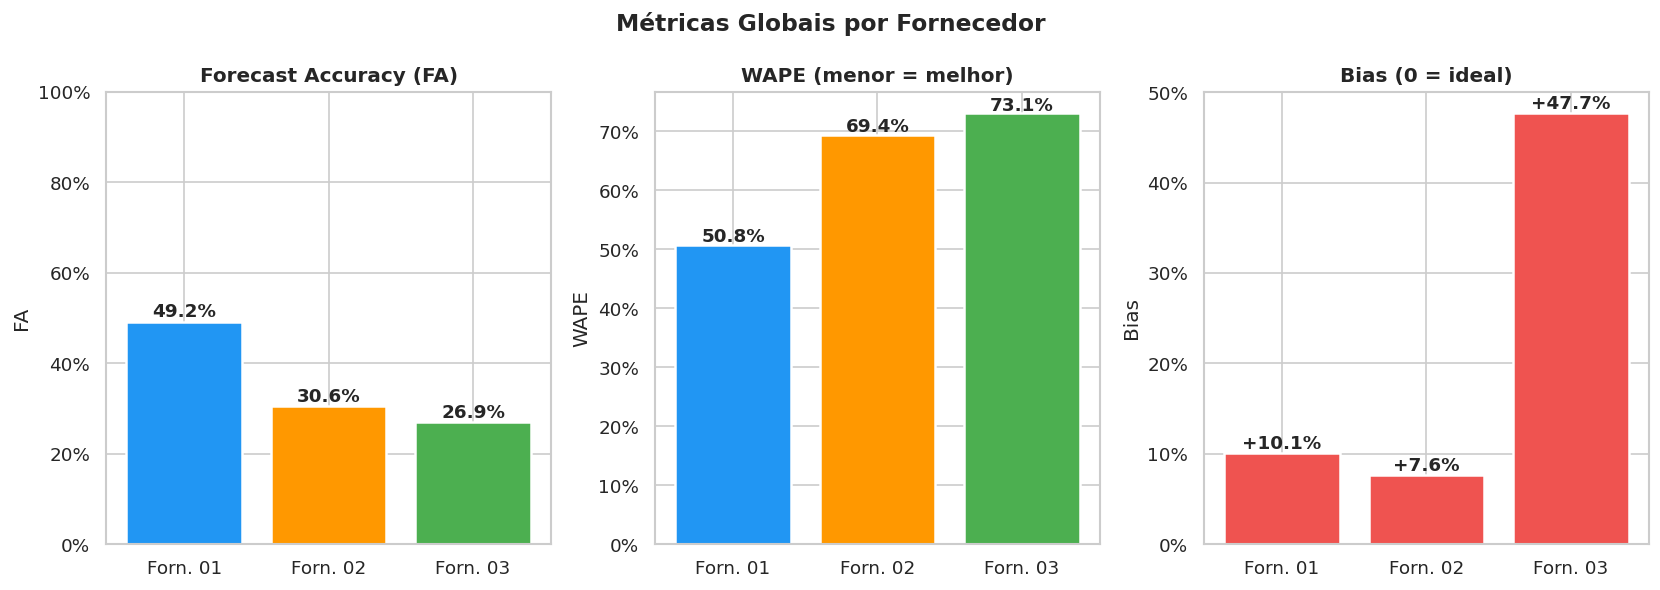

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Métricas Globais por Fornecedor', fontsize=14, fontweight='bold')

fornecedores_labels = [LABELS[f] for f in FORNECEDORES]
cores = [CORES[f] for f in FORNECEDORES]

fa_vals = [met_df.loc[LABELS[f], 'FA (Forecast Accuracy)'] for f in FORNECEDORES]
bars0 = axes[0].bar(fornecedores_labels, fa_vals, color=cores, edgecolor='white', linewidth=1.5)
axes[0].set_title('Forecast Accuracy (FA)', fontweight='bold')
axes[0].set_ylabel('FA')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].set_ylim(0, 1)
for bar, val in zip(bars0, fa_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.1%}', ha='center', fontsize=11, fontweight='bold')

wape_vals = [met_df.loc[LABELS[f], 'WAPE'] for f in FORNECEDORES]
bars1 = axes[1].bar(fornecedores_labels, wape_vals, color=cores, edgecolor='white', linewidth=1.5)
axes[1].set_title('WAPE (menor = melhor)', fontweight='bold')
axes[1].set_ylabel('WAPE')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
for bar, val in zip(bars1, wape_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.1%}', ha='center', fontsize=11, fontweight='bold')

bias_vals = [met_df.loc[LABELS[f], 'Bias'] for f in FORNECEDORES]
bar_colors = ['#ef5350' if b > 0 else '#66bb6a' for b in bias_vals]
bars2 = axes[2].bar(fornecedores_labels, bias_vals, color=bar_colors, edgecolor='white', linewidth=1.5)
axes[2].axhline(0, color='black', linewidth=1)
axes[2].set_title('Bias (0 = ideal)', fontweight='bold')
axes[2].set_ylabel('Bias')
axes[2].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
for bar, val in zip(bars2, bias_vals):
    ypos = bar.get_height() + 0.005 if val >= 0 else bar.get_height() - 0.02
    axes[2].text(bar.get_x() + bar.get_width()/2, ypos, f'{val:+.1%}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_01_metricas_globais.png', bbox_inches='tight')
plt.show()

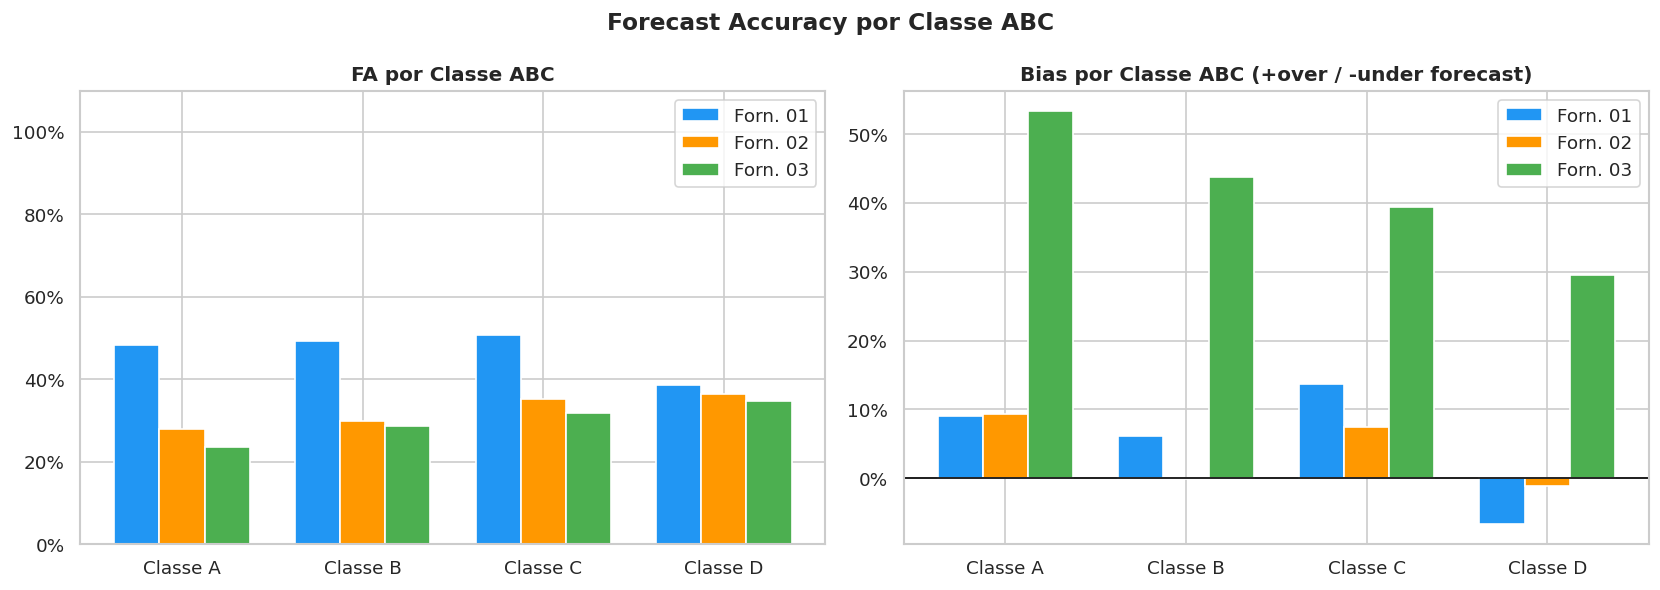

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Forecast Accuracy por Classe ABC', fontsize=14, fontweight='bold')

abc_order = sorted(df['CLASS_ABC'].unique())
x = np.arange(len(abc_order))
width = 0.25

for i, forn in enumerate(FORNECEDORES):
    fa_by_abc = []
    bias_by_abc = []
    for abc in abc_order:
        grp = df[df['CLASS_ABC'] == abc]
        fa_by_abc.append(forecast_accuracy(grp['VOLUME_REAL'], grp[f'VOLUME_{forn}']))
        bias_by_abc.append(bias(grp['VOLUME_REAL'], grp[f'VOLUME_{forn}']))
    axes[0].bar(x + i*width - width, fa_by_abc, width, label=LABELS[forn], color=CORES[forn], edgecolor='white')
    axes[1].bar(x + i*width - width, bias_by_abc, width, label=LABELS[forn], color=CORES[forn], edgecolor='white')

axes[0].set_title('FA por Classe ABC', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'Classe {a}' for a in abc_order])
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].legend()
axes[0].set_ylim(0, 1.1)

axes[1].set_title('Bias por Classe ABC (+over / -under forecast)', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'Classe {a}' for a in abc_order])
axes[1].axhline(0, color='black', linewidth=1)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_02_abc.png', bbox_inches='tight')
plt.show()

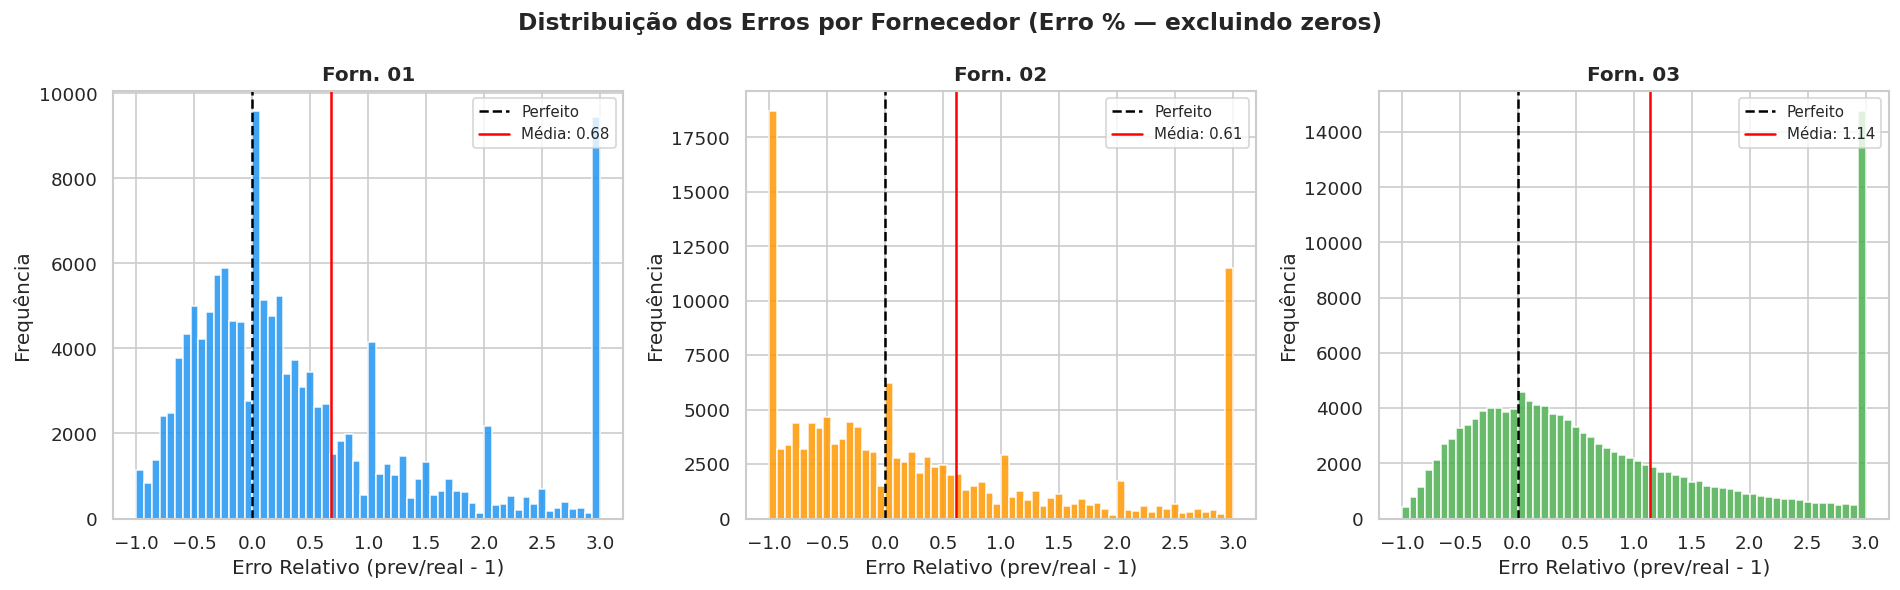

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribuição dos Erros por Fornecedor (Erro % — excluindo zeros)', fontsize=14, fontweight='bold')

for i, forn in enumerate(FORNECEDORES):
    erros = df[f'ERRO_PCT_{forn}'].dropna()
    erros_clip = erros.clip(-3, 3)
    axes[i].hist(erros_clip, bins=60, color=CORES[forn], edgecolor='white', alpha=0.85)
    axes[i].axvline(0, color='black', linewidth=1.5, linestyle='--', label='Perfeito')
    axes[i].axvline(erros.mean(), color='red', linewidth=1.5, linestyle='-', label=f'Média: {erros.mean():.2f}')
    axes[i].set_title(LABELS[forn], fontweight='bold')
    axes[i].set_xlabel('Erro Relativo (prev/real - 1)')
    axes[i].set_ylabel('Frequência')
    axes[i].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_03_dist_erros.png', bbox_inches='tight')
plt.show()

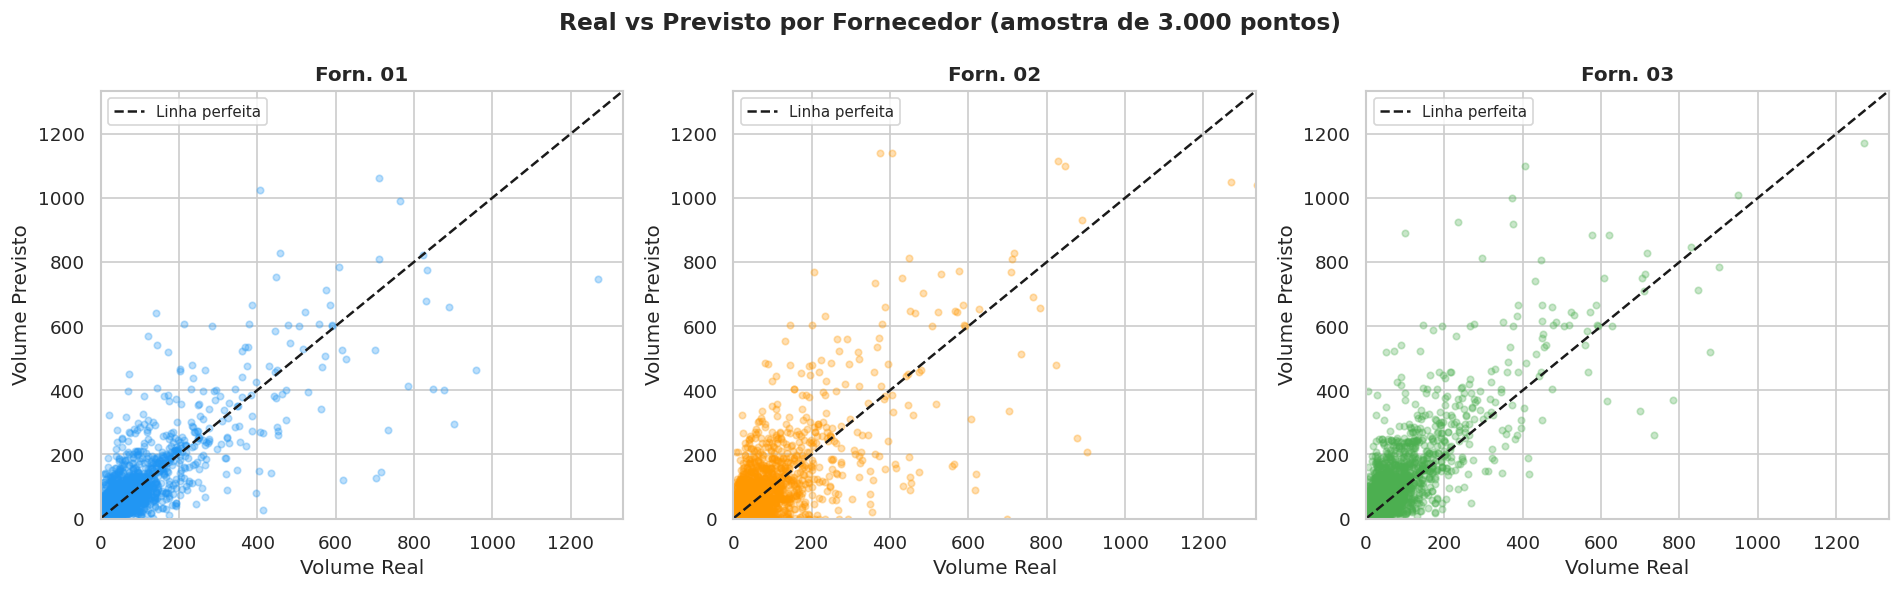

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Real vs Previsto por Fornecedor (amostra de 3.000 pontos)', fontsize=14, fontweight='bold')

sample = df[df['VOLUME_REAL'] > 0].sample(min(3000, len(df)), random_state=42)
max_val = max(sample['VOLUME_REAL'].max(),
              sample[['VOLUME_FORNECEDOR_01','VOLUME_FORNECEDOR_02','VOLUME_FORNECEDOR_03']].max().max())

for i, forn in enumerate(FORNECEDORES):
    col = f'VOLUME_{forn}'
    axes[i].scatter(sample['VOLUME_REAL'], sample[col], alpha=0.3, s=15, color=CORES[forn])
    axes[i].plot([0, max_val], [0, max_val], 'k--', linewidth=1.5, label='Linha perfeita')
    axes[i].set_title(LABELS[forn], fontweight='bold')
    axes[i].set_xlabel('Volume Real')
    axes[i].set_ylabel('Volume Previsto')
    axes[i].legend(fontsize=9)
    axes[i].set_xlim(0, max_val * 0.6)
    axes[i].set_ylim(0, max_val * 0.6)

plt.tight_layout()
plt.savefig('fig_04_scatter.png', bbox_inches='tight')
plt.show()

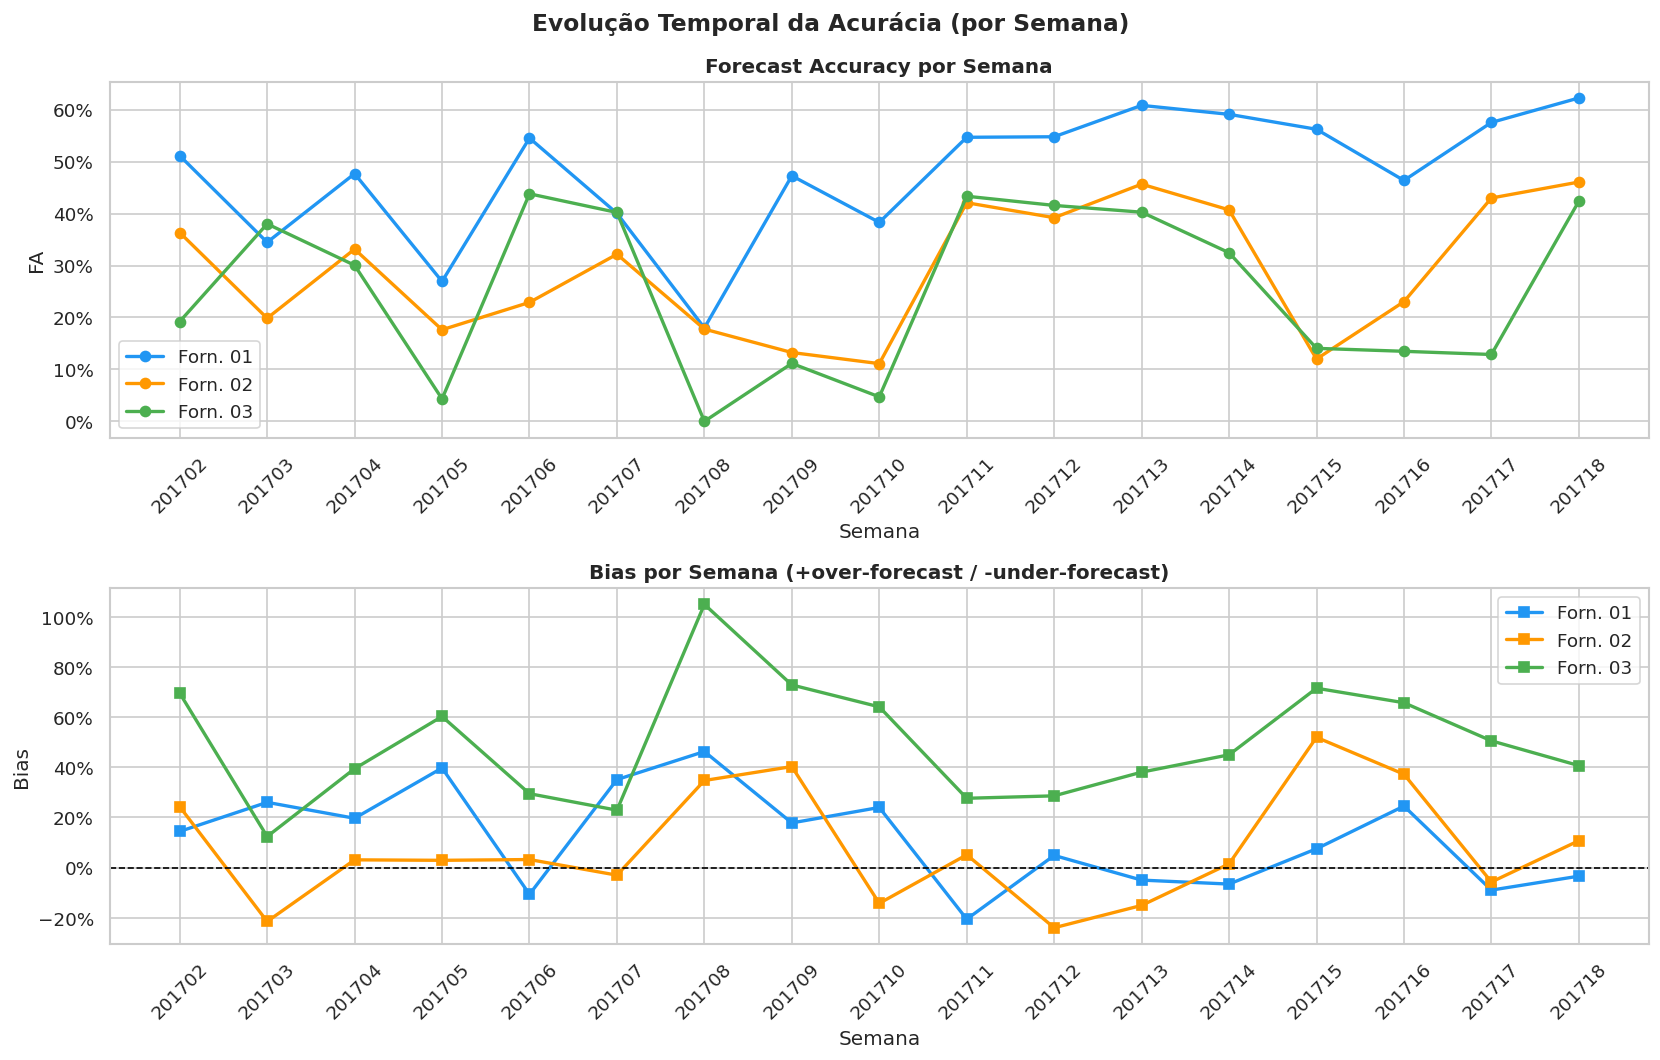

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle('Evolução Temporal da Acurácia (por Semana)', fontsize=14, fontweight='bold')

for forn in FORNECEDORES:
    forn_data = temp_df[temp_df['Fornecedor'] == LABELS[forn]]
    axes[0].plot(forn_data['Semana'], forn_data['FA'], marker='o', markersize=6,
                 label=LABELS[forn], color=CORES[forn], linewidth=2)
    axes[1].plot(forn_data['Semana'], forn_data['Bias'], marker='s', markersize=6,
                 label=LABELS[forn], color=CORES[forn], linewidth=2)

axes[0].set_title('Forecast Accuracy por Semana', fontweight='bold')
axes[0].set_ylabel('FA')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].legend()
axes[0].set_xticklabels(temp_df['Semana'].unique(), rotation=45)

axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_title('Bias por Semana (+over-forecast / -under-forecast)', fontweight='bold')
axes[1].set_ylabel('Bias')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].legend()
axes[1].set_xticklabels(temp_df['Semana'].unique(), rotation=45)

for ax in axes:
    ax.set_xlabel('Semana')
    ax.set_xticks(range(len(temp_df['Semana'].unique())))
    ax.set_xticklabels(sorted(temp_df['Semana'].unique()), rotation=45)

plt.tight_layout()
plt.savefig('fig_05_temporal.png', bbox_inches='tight')
plt.show()

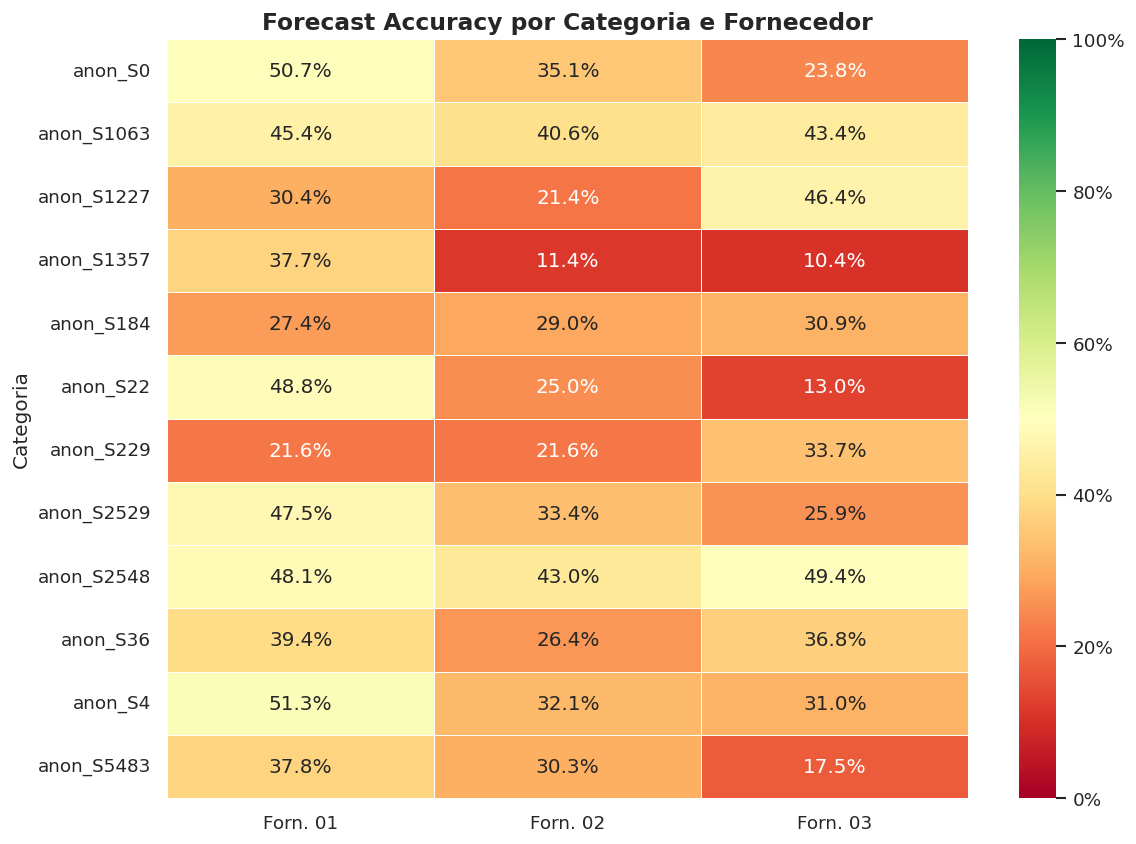

In [25]:
categorias = sorted(df['CATEGORIA'].unique())
heatmap_data = {}
for forn in FORNECEDORES:
    col = f'VOLUME_{forn}'
    fa_cat = []
    for cat in categorias:
        grp = df[df['CATEGORIA'] == cat]
        fa_cat.append(forecast_accuracy(grp['VOLUME_REAL'], grp[col]))
    heatmap_data[LABELS[forn]] = fa_cat

heatmap_df = pd.DataFrame(heatmap_data, index=categorias)

fig, ax = plt.subplots(figsize=(10, max(5, len(categorias) * 0.6)))
sns.heatmap(heatmap_df, annot=True, fmt='.1%', cmap='RdYlGn', vmin=0, vmax=1,
            linewidths=0.5, ax=ax, cbar_kws={'format': mticker.PercentFormatter(1.0)})
ax.set_title('Forecast Accuracy por Categoria e Fornecedor', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Categoria')
plt.tight_layout()
plt.savefig('fig_06_heatmap_cat.png', bbox_inches='tight')
plt.show()

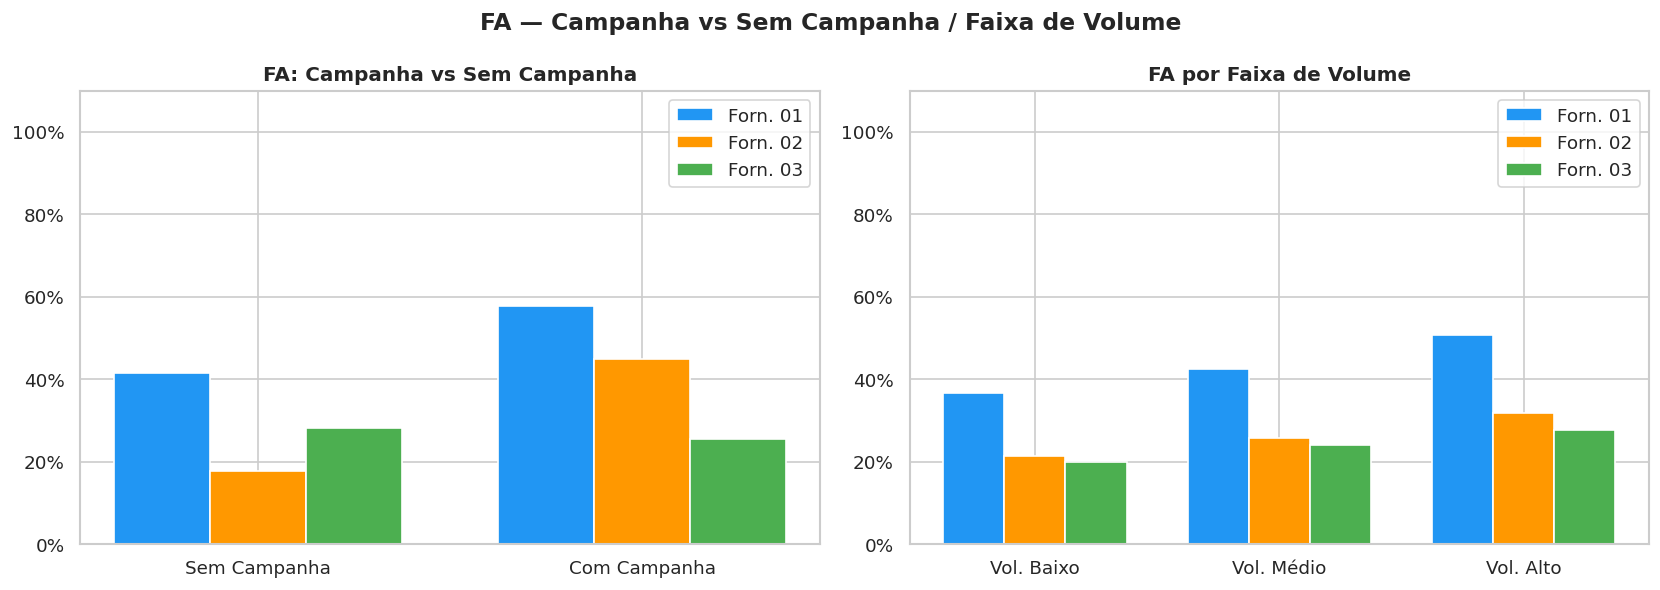

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('FA — Campanha vs Sem Campanha / Faixa de Volume', fontsize=14, fontweight='bold')

tipos_camp = ['Sem Campanha', 'Com Campanha']
x = np.arange(len(tipos_camp))
width = 0.25

for i, forn in enumerate(FORNECEDORES):
    fa_vals_camp = []
    for flag, label in [(0, 'Sem Campanha'), (1, 'Com Campanha')]:
        grp = df[df['CAMPANHA_FLAG'] == flag]
        fa_vals_camp.append(forecast_accuracy(grp['VOLUME_REAL'], grp[f'VOLUME_{forn}']))
    axes[0].bar(x + i*width - width, fa_vals_camp, width, label=LABELS[forn], color=CORES[forn], edgecolor='white')

axes[0].set_title('FA: Campanha vs Sem Campanha', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(tipos_camp)
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].legend()
axes[0].set_ylim(0, 1.1)

faixas = ['Baixo', 'Médio', 'Alto']
x2 = np.arange(len(faixas))
for i, forn in enumerate(FORNECEDORES):
    fa_faixa = []
    for f in faixas:
        grp = df[df['FAIXA_VOLUME'] == f]
        fa_faixa.append(forecast_accuracy(grp['VOLUME_REAL'], grp[f'VOLUME_{forn}']))
    axes[1].bar(x2 + i*width - width, fa_faixa, width, label=LABELS[forn], color=CORES[forn], edgecolor='white')

axes[1].set_title('FA por Faixa de Volume', fontweight='bold')
axes[1].set_xticks(x2)
axes[1].set_xticklabels([f'Vol. {f}' for f in faixas])
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].legend()
axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig('fig_07_campanha_volume.png', bbox_inches='tight')
plt.show()

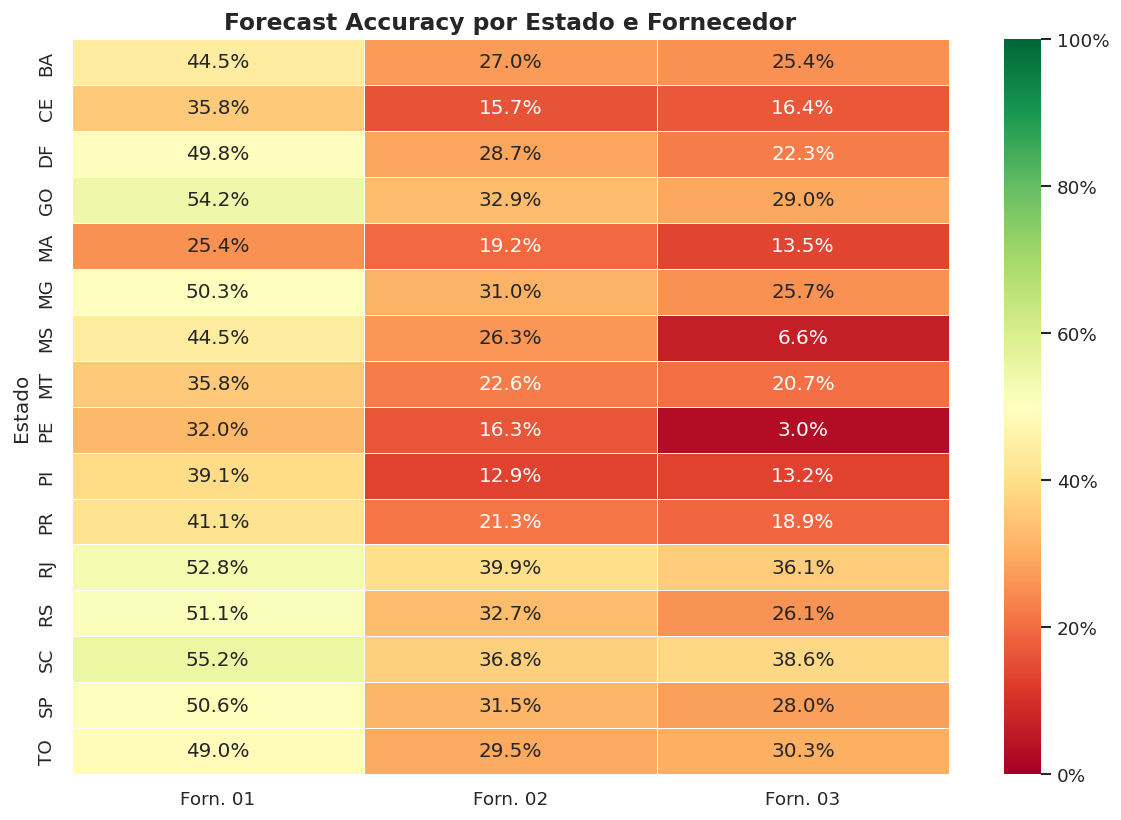

In [27]:
estados = sorted(df['ESTADO'].unique())
heatmap_est = {}
for forn in FORNECEDORES:
    col = f'VOLUME_{forn}'
    fa_est = []
    for est in estados:
        grp = df[df['ESTADO'] == est]
        fa_est.append(forecast_accuracy(grp['VOLUME_REAL'], grp[col]))
    heatmap_est[LABELS[forn]] = fa_est

heatmap_est_df = pd.DataFrame(heatmap_est, index=estados)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(heatmap_est_df, annot=True, fmt='.1%', cmap='RdYlGn', vmin=0, vmax=1,
            linewidths=0.5, ax=ax, cbar_kws={'format': mticker.PercentFormatter(1.0)})
ax.set_title('Forecast Accuracy por Estado e Fornecedor', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Estado')
plt.tight_layout()
plt.savefig('fig_08_heatmap_estado.png', bbox_inches='tight')
plt.show()

## 8. Placar Final e Recomendação

In [28]:
scorecard = []
for forn in FORNECEDORES:
    col = f'VOLUME_{forn}'
    real = df['VOLUME_REAL']
    prev = df[col]

    real_a = df[df['CLASS_ABC']=='A']['VOLUME_REAL']
    prev_a = df[df['CLASS_ABC']=='A'][col]

    camp_on_real = df[df['CAMPANHA_FLAG']==1]['VOLUME_REAL']
    camp_on_prev = df[df['CAMPANHA_FLAG']==1][col]

    scorecard.append({
        'Fornecedor': LABELS[forn],
        '① FA Global': forecast_accuracy(real, prev),
        '② FA Classe A': forecast_accuracy(real_a, prev_a),
        '③ FA c/ Campanha': forecast_accuracy(camp_on_real, camp_on_prev),
        '④ Bias Global': abs(bias(real, prev)),
        '⑤ FA Top-20 SKUs': forecast_accuracy(df_top20['VOLUME_REAL'], df_top20[col]),
        '⑥ Consistência (Std FA)': temp_df[temp_df['Fornecedor']==LABELS[forn]]['FA'].std(),
    })

sc_df = pd.DataFrame(scorecard).set_index('Fornecedor')

print('============================================')
print('         SCORECARD FINAL DE FORNECEDORES   ')
print('============================================')
display(sc_df.style.format({
    '① FA Global': '{:.2%}',
    '② FA Classe A': '{:.2%}',
    '③ FA c/ Campanha': '{:.2%}',
    '④ Bias Global': '{:.2%}',
    '⑤ FA Top-20 SKUs': '{:.2%}',
    '⑥ Consistência (Std FA)': '{:.4f}',
}).highlight_max(subset=['① FA Global','② FA Classe A','③ FA c/ Campanha','⑤ FA Top-20 SKUs'], color='#c8e6c9')\
  .highlight_min(subset=['④ Bias Global','⑥ Consistência (Std FA)'], color='#c8e6c9'))

         SCORECARD FINAL DE FORNECEDORES   


,① FA Global,② FA Classe A,③ FA c/ Campanha,④ Bias Global,⑤ FA Top-20 SKUs,⑥ Consistência (Std FA)
Fornecedor,,,,,,
Forn. 01,49.20%,48.43%,57.87%,10.09%,55.86%,0.1245
Forn. 02,30.59%,27.97%,44.99%,7.62%,38.78%,0.1257
Forn. 03,26.92%,23.69%,25.60%,47.67%,31.15%,0.1594


In [29]:
pesos = {
    '① FA Global': 0.30,
    '② FA Classe A': 0.25,
    '③ FA c/ Campanha': 0.20,
    '⑤ FA Top-20 SKUs': 0.15,
    '⑥ Consistência (Std FA)': 0.10,
}

score_norm = sc_df.copy()
for col in ['① FA Global','② FA Classe A','③ FA c/ Campanha','⑤ FA Top-20 SKUs']:
    col_min, col_max = score_norm[col].min(), score_norm[col].max()
    if col_max > col_min:
        score_norm[col] = (score_norm[col] - col_min) / (col_max - col_min)
    else:
        score_norm[col] = 1.0

col_std = '⑥ Consistência (Std FA)'
col_min, col_max = score_norm[col_std].min(), score_norm[col_std].max()
if col_max > col_min:
    score_norm[col_std] = 1 - (score_norm[col_std] - col_min) / (col_max - col_min)
else:
    score_norm[col_std] = 1.0

score_norm['SCORE FINAL'] = sum(
    score_norm[col] * peso for col, peso in pesos.items()
)

ranking = score_norm[['SCORE FINAL']].sort_values('SCORE FINAL', ascending=False)
ranking['Posição'] = range(1, len(ranking)+1)

print('=== RANKING FINAL PONDERADO ===')
display(ranking.style.format({'SCORE FINAL': '{:.3f}'}).highlight_max(subset=['SCORE FINAL'], color='#c8e6c9'))

=== RANKING FINAL PONDERADO ===


,SCORE FINAL,Posição
Fornecedor,,
Forn. 01,1.000,1
Forn. 02,0.356,2
Forn. 03,0.000,3


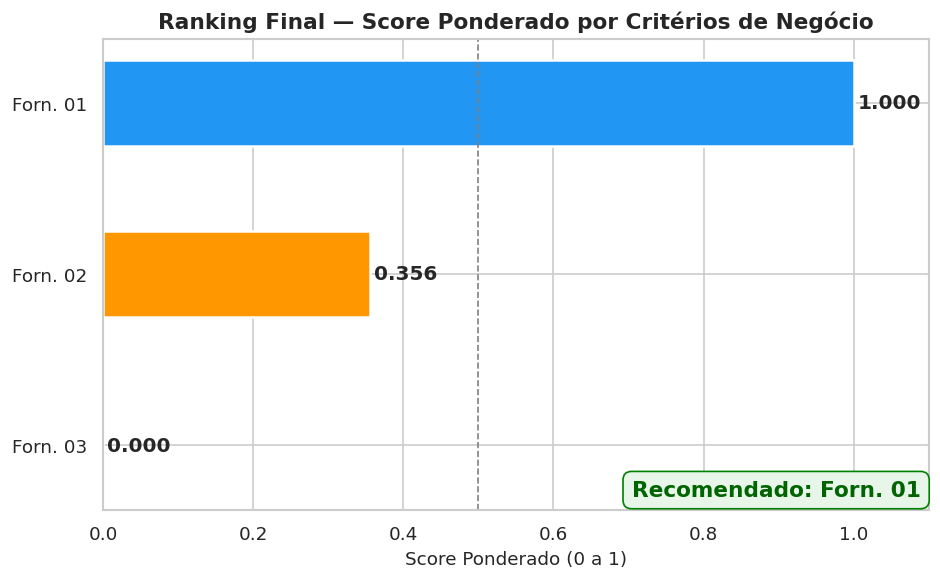

In [30]:
vencedor = ranking.index[0]

fig, ax = plt.subplots(figsize=(8, 5))
fornecedores_ord = ranking.index.tolist()
scores_ord = ranking['SCORE FINAL'].tolist()
cores_ord = [CORES[FORNECEDORES[[LABELS[f] for f in FORNECEDORES].index(v)]] for v in fornecedores_ord]

bars = ax.barh(fornecedores_ord[::-1], scores_ord[::-1], color=cores_ord[::-1], edgecolor='white', linewidth=1.5, height=0.5)
for bar, val in zip(bars, scores_ord[::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontweight='bold', fontsize=12)

ax.set_xlim(0, 1.1)
ax.set_xlabel('Score Ponderado (0 a 1)', fontsize=11)
ax.set_title('Ranking Final — Score Ponderado por Critérios de Negócio', fontsize=13, fontweight='bold')
ax.axvline(0.5, color='gray', linewidth=1, linestyle='--')

ax.text(0.99, 0.02, f'Recomendado: {vencedor}', transform=ax.transAxes,
        fontsize=13, fontweight='bold', color='darkgreen',
        ha='right', va='bottom',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#e8f5e9', edgecolor='green'))

plt.tight_layout()
plt.savefig('fig_09_ranking_final.png', bbox_inches='tight')
plt.show()

In [31]:
print('=' * 60)
print('  RELATÓRIO DE RECOMENDAÇÃO — SELEÇÃO DE FORNECEDOR')
print('=' * 60)

for forn in FORNECEDORES:
    lbl = LABELS[forn]
    col = f'VOLUME_{forn}'
    real = df['VOLUME_REAL']
    prev = df[col]
    fa_g = forecast_accuracy(real, prev)
    wape_g = wape(real, prev)
    bias_g = bias(real, prev)

    real_a = df[df['CLASS_ABC']=='A']['VOLUME_REAL']
    prev_a = df[df['CLASS_ABC']=='A'][col]
    fa_a = forecast_accuracy(real_a, prev_a)

    camp_real = df[df['CAMPANHA_FLAG']==1]['VOLUME_REAL']
    camp_prev = df[df['CAMPANHA_FLAG']==1][col]
    fa_camp = forecast_accuracy(camp_real, camp_prev)

    score = ranking.loc[lbl, 'SCORE FINAL']
    pos = ranking.loc[lbl, 'Posição']

    eh_vencedor = ' *** RECOMENDADO ***' if lbl == vencedor else ''
    print(f'\n[{pos}º] {lbl}{eh_vencedor}')
    print(f'  Score Final : {score:.3f}')
    print(f'  FA Global   : {fa_g:.2%}')
    print(f'  WAPE Global : {wape_g:.2%}')
    print(f'  Bias        : {bias_g:+.2%}  ({"over-forecast" if bias_g > 0 else "under-forecast"})')
    print(f'  FA Classe A : {fa_a:.2%}')
    print(f'  FA Campanha : {fa_camp:.2%}')

print('\n' + '=' * 60)
print(f'  RECOMENDAÇÃO FINAL: {vencedor}')
print('=' * 60)
print("""
METODOLOGIA DE PONTUAÇÃO:
  30% — FA Global           (acurácia geral do portfólio)
  25% — FA Classe A         (impacto financeiro maior)
  20% — FA com Campanha     (capacidade de prever picos)
  15% — FA Top-20 SKUs      (SKUs de maior volume/criticidade)
  10% — Consistência Semanal (estabilidade do modelo)

PONTOS CRÍTICOS AVALIADOS:
  ✓ Acurácia global no portfólio completo (WAPE / FA)
  ✓ Qualidade nos itens classe A (maior impacto no estoque)
  ✓ Capacidade de prever picos promocionais
  ✓ Direção do viés (over vs under-forecast)
  ✓ Consistência e estabilidade ao longo do tempo
  ✓ Cobertura geográfica (FA por estado)
""")

  RELATÓRIO DE RECOMENDAÇÃO — SELEÇÃO DE FORNECEDOR

[1º] Forn. 01 *** RECOMENDADO ***
  Score Final : 1.000
  FA Global   : 49.20%
  WAPE Global : 50.80%
  Bias        : +10.09%  (over-forecast)
  FA Classe A : 48.43%
  FA Campanha : 57.87%

[2º] Forn. 02
  Score Final : 0.356
  FA Global   : 30.59%
  WAPE Global : 69.41%
  Bias        : +7.62%  (over-forecast)
  FA Classe A : 27.97%
  FA Campanha : 44.99%



[3º] Forn. 03
  Score Final : 0.000
  FA Global   : 26.92%
  WAPE Global : 73.08%
  Bias        : +47.67%  (over-forecast)
  FA Classe A : 23.69%
  FA Campanha : 25.60%

  RECOMENDAÇÃO FINAL: Forn. 01

METODOLOGIA DE PONTUAÇÃO:
  30% — FA Global           (acurácia geral do portfólio)
  25% — FA Classe A         (impacto financeiro maior)
  20% — FA com Campanha     (capacidade de prever picos)
  15% — FA Top-20 SKUs      (SKUs de maior volume/criticidade)
  10% — Consistência Semanal (estabilidade do modelo)

PONTOS CRÍTICOS AVALIADOS:
  ✓ Acurácia global no portfólio completo (WAPE / FA)
  ✓ Qualidade nos itens classe A (maior impacto no estoque)
  ✓ Capacidade de prever picos promocionais
  ✓ Direção do viés (over vs under-forecast)
  ✓ Consistência e estabilidade ao longo do tempo
  ✓ Cobertura geográfica (FA por estado)

